# Model Trainer

## Imports

In [87]:
import os
import re

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"  # 1
os.environ[
    "XLA_FLAGS"
] = "--xla_gpu_cuda_data_dir=/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/"

import tensorflow as tf

keras = tf.keras  # fixes issues with vsCode
from keras import backend as K
import numpy as np
import matplotlib.pyplot as plt

from functools import partial

from keras import Input, Model
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import (
    Layer,
    LeakyReLU,
    Add,
    UpSampling2D,
    Activation,
    SpatialDropout2D,
    Conv2D,
    BatchNormalization,
    Concatenate,
    Flatten,
    Dense,
    RandomRotation,
    RandomFlip,
    RandomZoom,
)
from keras.optimizers import Adam
from tensorflow_addons.layers import InstanceNormalization

from IPython.display import clear_output
from datetime import datetime

from tensorflow import pad

from keras.callbacks import (
    LambdaCallback,
    TensorBoard,
    EarlyStopping,
    ModelCheckpoint,
    LearningRateScheduler,
)

# %matplotlib inline

# tf.debugging.set_log_device_placement(False)

print(f"tf version: {tf.__version__}")
plt.rcParams.update({"font.size": 13})
tf.config.list_physical_devices("GPU")

tf version: 2.11.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

We used MirroredStrategy to allow for multiGPU setups, can use onedevice if you need to debug things and don't want to change server settings.

In [88]:
strategy = tf.distribute.MirroredStrategy()
# stragety = tf.distribute.OneDeviceStrategy(device="/gpu:0") # for debugging

[ tensorflow - _initialize_strategy() ] | INFO : Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


Lets make the folders to support our stuff. You can disable tensorboard support here if you want

In [89]:
# some base settings for files
model_name = "camb"
data_dir = f"data/{model_name}"
model_dir = f"data/models/{model_name}"
plot_dir = f"data/plots/{model_name}"
tb_dir = f"data/tensorboard/{model_name}"

use_tensorboard = True

def mk_dir(dir):
    if not os.path.exists(dir):
        print(f"Creating dir: {dir}")
        os.makedirs(dir)
    else:
        print(f'Using existing folder {dir}')

mk_dir(data_dir)
mk_dir(model_dir)
mk_dir(plot_dir)
if use_tensorboard:
    mk_dir(tb_dir)

Using existing folder data/camb
Using existing folder data/models/camb
Using existing folder data/plots/camb
Using existing folder data/tensorboard/camb


## TensorBoard

Will launch an in-notebook tensorboard session, might need to change port. This works in VSCode but not sure about jupyter proper

In [90]:
# %load_ext tensorboard
# %tensorboard --logdir data/tensorboard/ --port 23465
# print('open http://localhost:23465/')

## Model Code

In [91]:
def load_data(data_dir, base_name):
    # load fnls, which are in the base dir
    fnls = np.load(f"{data_dir}/{base_name}-fnls.npy")

    # List all files in data_dir
    all_files = os.listdir(data_dir)

    # Filter files that match the base_name and specific format
    pattern = re.compile(f"{base_name}_\d+-\d+\.npy")
    filtered_files = [file for file in all_files if pattern.match(file)]

    # Sort files based on the first range value
    filtered_files.sort(key=lambda x: int(re.search("\d+", x).group()))

    # Load data from files and append to a list
    data_list = []
    for file in filtered_files:
        file_path = os.path.join(data_dir, file)
        print(f'loading {file_path}')
        data = np.load(file_path)
        data_list.append(data)

    # Concatenate data into a single numpy array
    data_array = np.concatenate(data_list, axis=0)

    return data_array, fnls

### Helper Functions

In [92]:
class ReflectionPadding2D(Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        self.input_spec = [tf.keras.layers.InputSpec(ndim=4)]
        super(ReflectionPadding2D, self).__init__(**kwargs)

    def compute_output_shape(self, s):
        """If you are using "channels_last" configuration"""
        return (s[0], s[1] + 2 * self.padding[0], s[2] + 2 * self.padding[1], s[3])

    def call(self, x, mask=None):
        w_pad, h_pad = self.padding
        return pad(x, [[0, 0], [h_pad, h_pad], [w_pad, w_pad], [0, 0]], "REFLECT")


def create_localization_module(input_layer, n_filters):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(layer1, n_filters)
    return create_convolution_block(convolution1, n_filters, kernel=(1, 1))


def create_up_sampling_module(input_layer, n_filters, size=(2, 2)):
    up_sample = UpSampling2D(size=size)(input_layer)
    layer1 = ReflectionPadding2D()(up_sample)
    return create_convolution_block(layer1, n_filters)


def create_context_module(
    input_layer, n_level_filters, dropout_rate=0.1, data_format="channels_last"
):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(
        input_layer=layer1, n_filters=n_level_filters
    )
    dropout = SpatialDropout2D(rate=dropout_rate, data_format=data_format)(convolution1)
    layer2 = ReflectionPadding2D()(dropout)
    return create_convolution_block(
        input_layer=layer2, n_filters=n_level_filters
    )


def create_convolution_block(
    input_layer,
    n_filters,
    batch_normalization=False,
    kernel=(3, 3),
    activation=LeakyReLU,
    padding="valid",
    strides=(1, 1),
    instance_normalization=False,
):
    """
    :param strides:
    :param input_layer:
    :param n_filters:
    :param batch_normalization:
    :param kernel:
    :param activation: Keras activation layer to use. (default is 'relu')
    :param padding:
    :return:
    """
    layer = Conv2D(n_filters, kernel, padding=padding, strides=strides)(input_layer)
    if batch_normalization:
        layer = BatchNormalization()(layer)
    elif instance_normalization:
        layer = InstanceNormalization()(layer)
    return Activation("relu")(layer) if activation is None else activation()(layer)


def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_coefficient_loss(y_true, y_pred):
    return -dice_coefficient(y_true, y_pred)

### Model Architecture

#### isensee2017

In [93]:
with strategy.scope():
    create_convolution_block = partial(
        create_convolution_block, activation=LeakyReLU, instance_normalization=True
    )


def isensee2017_model(
    inputs,
    n_base_filters=16,
    depth=5,
    dropout_rate=0.3,
    n_segmentation_levels=3,
    n_labels=1,
    optimizer=Adam,
    initial_learning_rate=5e-4,
    loss_function=dice_coefficient_loss,
    activation_name="relu",
    preprocess=False,
):
    """
    This function builds a model proposed by Isensee et al. for the BRATS 2017 competition:
    https://www.cbica.upenn.edu/sbia/Spyridon.Bakas/MICCAI_BraTS/MICCAI_BraTS_2017_proceedings_shortPapers.pdf
    This network is highly similar to the model proposed by Kayalibay et al. "CNN-based Segmentation of Medical
    Imaging Data", 2017: https://arxiv.org/pdf/1701.03056.pdf
    :param inputs:
    :param n_base_filters:
    :param depth:
    :param dropout_rate:
    :param n_segmentation_levels:
    :param n_labels:
    :param optimizer:
    :param initial_learning_rate:
    :param loss_function:
    :param activation_name:
    :return:
    """
    if preprocess:
        inputs = RandomFlip("horizontal")(inputs)
        # inputs = RandomZoom(0.2)(inputs)
        inputs = RandomRotation(np.pi)(inputs)

    current_layer = inputs
    level_output_layers = []
    level_filters = []
    # n_level_filters = (2**level_number) * n_base_filters
    n_level_filters = 8
    for _ in range(depth):
        level_filters.append(n_level_filters)

        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(
            in_conv, n_level_filters, dropout_rate=dropout_rate
        )

        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    segmentation_layers = []
    for level_number in range(depth - 2, -1, -1):
        up_sampling = create_up_sampling_module(
            current_layer, level_filters[level_number]
        )
        concatenation_layer = Concatenate()(
            [level_output_layers[level_number], up_sampling]
        )
        localization_output = create_localization_module(
            concatenation_layer, level_filters[level_number]
        )
        current_layer = localization_output
        if level_number < n_segmentation_levels:
            segmentation_layers.insert(0, Conv2D(n_labels, (1, 1))(current_layer))

    output_layer = None
    for level_number in reversed(range(n_segmentation_levels - 1)):
        segmentation_layer = segmentation_layers[level_number]
        if output_layer is None:
            output_layer = segmentation_layer
        else:
            output_layer = Add()([output_layer, segmentation_layer])

        if level_number > 0:
            output_layer = UpSampling2D(size=(2, 2))(output_layer)

    flat_layer = Flatten()(output_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer)
    model.compile(
        optimizer=optimizer(learning_rate=initial_learning_rate),
        loss=loss_function,
        metrics=tf.keras.metrics.RootMeanSquaredError(),
    )
    return model

#### Custom BS

In [94]:
def make_model(
    inputs,
    n_base_filters=16,
    depth=5,
    dropout_rate=0.3,
    n_segmentation_levels=3,
    n_labels=1,
    optimizer=Adam,
    initial_learning_rate=5e-4,
    loss_function=dice_coefficient_loss,
    activation_name="relu",
    name="custom_model",
    preprocess=False,
):
    """
    This function builds a model proposed by Isensee et al. for the BRATS 2017 competition:
    https://www.cbica.upenn.edu/sbia/Spyridon.Bakas/MICCAI_BraTS/MICCAI_BraTS_2017_proceedings_shortPapers.pdf
    This network is highly similar to the model proposed by Kayalibay et al. "CNN-based Segmentation of Medical
    Imaging Data", 2017: https://arxiv.org/pdf/1701.03056.pdf
    :param inputs:
    :param n_base_filters:
    :param depth:
    :param dropout_rate:
    :param n_segmentation_levels:
    :param n_labels:
    :param optimizer:
    :param initial_learning_rate:
    :param loss_function:
    :param activation_name:
    :return:
    """
    if preprocess:
        inputs = RandomFlip("horizontal")(inputs)
        inputs = RandomZoom(0.2)(inputs)
        inputs = RandomRotation(np.pi)(inputs)

    current_layer = inputs
    level_output_layers = []
    level_filters = []
    n_level_filters = 16  # 2**(depth-level_number) #* n_base_filters
    for _ in range(depth):
        level_filters.append(n_level_filters)

        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(
            in_conv, n_level_filters, dropout_rate=dropout_rate
        )
        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    flat_layer = Flatten()(current_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer, name=name)
    model.compile(
        optimizer=optimizer(learning_rate=initial_learning_rate),
        loss=loss_function,
        metrics=tf.keras.metrics.RootMeanSquaredError(),
    )
    return model

## Load Data

In [95]:
# These settings should match the generation settings, from there it will just load the files correctly
img_size = 128
train_size_k = 10
train_size = train_size_k * 1000
fnl_range = [-1000, 1000]

basename = f"{img_size}x{train_size_k}k_fnl{fnl_range[0]}-{fnl_range[1]}"
run_time = datetime.now().strftime("%Y%m%d-%H%M%S")

# update data_dir to match conventions
data_dir = f"{data_dir}/{basename}"

# model settins, will also be used to inform data loading
batch_size = 512
max_epochs = 100

In [96]:
N_train = int(train_size * 0.8)
N_val = int(train_size * 0.1)
N_test = int(train_size * 0.1)

data, fnls = load_data(data_dir, basename)

# split into training and testing data
X_train = data[:N_train]
X_test = data[N_train : N_train + N_test]
X_val = data[N_train + N_test : N_train + N_test + N_val]

y_train = fnls[:N_train]
y_test = fnls[N_train : N_train + N_test]
y_val = fnls[N_train + N_test : N_train + N_test + N_val]

print(
    X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape
)

# Our sets are not big enought to do really complex loading into ram, but we still need to do stuff for the gpu
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

loading data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_0-10000.npy
(8000, 128, 128) (1000, 128, 128) (1000, 128, 128) (8000,) (1000,) (1000,)


### Check Data

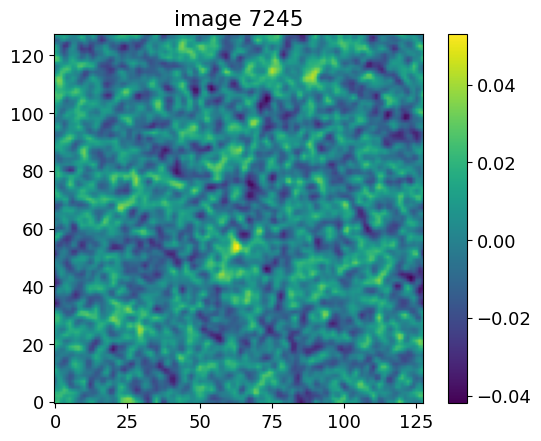

In [97]:
ri = np.random.randint(len(data))
plt.imshow(data[ri], origin="lower")
plt.title(f"image {ri}")
plt.colorbar()
plt.show()

## Train Model

### Compile Model

In [98]:
with strategy.scope():
    input_img = Input((img_size, img_size, 1), name="img")
    model = isensee2017_model(
        input_img,
        depth=5,
        n_segmentation_levels=3,
        dropout_rate=0.3,
        loss_function=tf.keras.losses.mse,
        initial_learning_rate=1e-3,
        preprocess=True
    )
    model.summary()

#     model = make_model(
#         input_img,
#         depth=2,
#         n_segmentation_levels=0,
#         dropout_rate=0.3,
#         loss_function=tf.keras.losses.mse,
#         initial_learning_rate=1e-3,
#         preprocess=False,
#         name=f"{model_name}-{basename}",
#     )
#     model.summary()

[ tensorflow -  _fallback_converter() ] | WARNING : Using a while_loop for converting RngReadAndSkip cause there is no registered converter for this op.
[ tensorflow -  _fallback_converter() ] | WARNING : Using a while_loop for converting Bitcast cause there is no registered converter for this op.
[ tensorflow -  _fallback_converter() ] | WARNING : Using a while_loop for converting Bitcast cause there is no registered converter for this op.
[ tensorflow -  _fallback_converter() ] | WARNING : Using a while_loop for converting StatelessRandomUniformV2 cause there is no registered converter for this op.
[ tensorflow -  _fallback_converter() ] | WARNING : Using a while_loop for converting ImageProjectiveTransformV3 cause there is no registered converter for this op.
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (In

### Train

In [99]:
# Help keep the output clean in VS Code, might want to remove this if you're not using VS Code
def clearOutput(batch, logs):
    clear_output(wait=True)


with strategy.scope():
    K.set_value(model.optimizer.learning_rate, 1e-3)

    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-5, decay_steps=10000, decay_rate=0.9
    )

    callbacks = [
        EarlyStopping(monitor="val_root_mean_squared_error", patience=10),
        ModelCheckpoint(
            filepath=f"{model_dir}/checkpoint_{run_time}.keras",
            monitor="val_root_mean_squared_error",
            save_best_only=True,
        ),
        # LearningRateScheduler(lr_schedule),
        LambdaCallback(on_epoch_begin=clearOutput),
    ]
    if use_tensorboard:
        logs = f"{tb_dir}/{basename}_{run_time}"
        callbacks.append(TensorBoard(log_dir=logs))

    model.fit(
        train_dataset,
        validation_data=val_dataset,
        batch_size=batch_size,
        epochs=max_epochs,
        callbacks=callbacks,
    )

Epoch 100/100
16/16 [==============================] - 14s 877ms/step - loss: 14.3428 - root_mean_squared_error: 3.7872 - val_loss: 0.8763 - val_root_mean_squared_error: 0.9361


### Validation

Simple validation checks on the three datasets. The model has seen train and val before, so those results are not as important as the test results which have not been seen by the model yet.

16/16 [==============================] - 5s 143ms/step


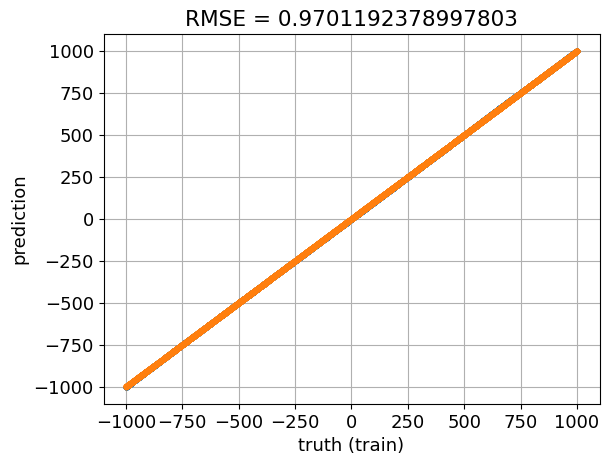

In [101]:
# check the accuracy of some training data
preds = model.predict(X_train, batch_size=batch_size, verbose="auto")[:, 0]
truth = y_train
rmse = np.sqrt(((preds - truth) ** 2).mean())

plt.plot(truth, preds, ".")
plt.plot(truth, truth, ".")
plt.title(f"RMSE = {rmse}")
plt.xlabel("truth (train)")
plt.grid()
plt.ylabel("prediction")

plt.savefig(f"{plot_dir}/{basename}_train.png")
plt.show()

2/2 [==============================] - 0s 142ms/step


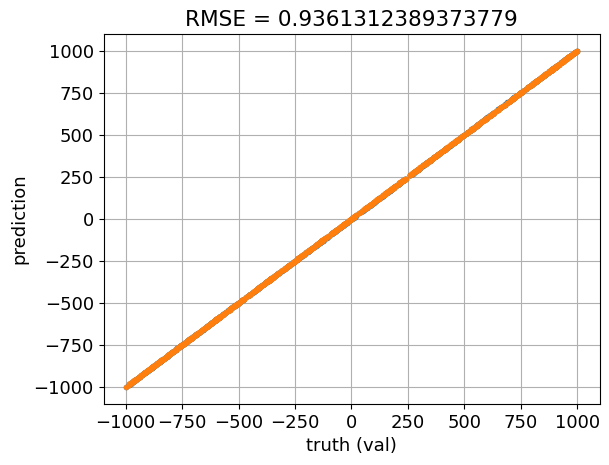

In [103]:
# check the accuracy of some training data
preds = model.predict(X_val, batch_size=batch_size, verbose="auto")[:, 0]
truth = y_val
rmse = np.sqrt(((preds - truth) ** 2).mean())

plt.plot(truth, preds, ".")
plt.plot(truth, truth, ".")
plt.title(f"RMSE = {rmse}")
plt.xlabel("truth (val)")
plt.grid()
plt.ylabel("prediction")

plt.savefig(f"{plot_dir}/{basename}_val.png")
plt.show()

2/2 [==============================] - 0s 142ms/step


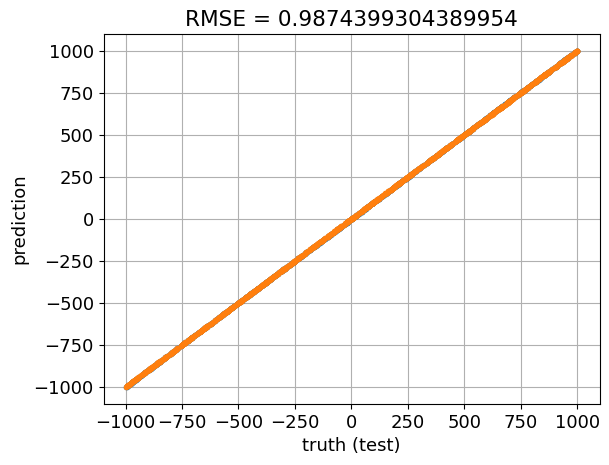

In [105]:
# check the accuracy of some training data
preds = model.predict(X_test, batch_size=batch_size, verbose="auto")[:, 0]
truth = y_test
rmse = np.sqrt(((preds - truth) ** 2).mean())

plt.plot(truth, preds, ".")
plt.plot(truth, truth, ".")
plt.title(f"RMSE = {rmse}")
plt.xlabel("truth (test)")
plt.grid()
plt.ylabel("prediction")

plt.savefig(f"{plot_dir}/{basename}_test.png")
plt.show()

### Save Model

In [107]:
modelfile = f"{model_dir}/{basename}_{run_time}"
model.save(modelfile)

[ absl -             __init__() ] | WARNING : Found untraced functions such as _jit_compiled_convolution_op, _jit_compiled_convolution_op, _jit_compiled_convolution_op, _jit_compiled_convolution_op, _jit_compiled_convolution_op while saving (showing 5 of 29). These functions will not be directly callable after loading.
[ tensorflow - copy_assets_to_destination_dir() ] | INFO : Assets written to: data/models/camb/128x10k_fnl-1000-1000_20230507-120915/assets
